In [5]:
import pandas as pd
import numpy as np
import requests
import io
from sklearn import preprocessing
from sklearn.model_selection import train_test_split

URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
df = pd.read_csv(io.BytesIO(requests.get(URL).content))

features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
X = pd.get_dummies(features, columns=['Orbit', 'LaunchSite', 'LandingPad', 'Serial'])
Y = df['Class'].to_numpy()

X_scaled = preprocessing.StandardScaler().fit_transform(X.astype(float))
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=2)

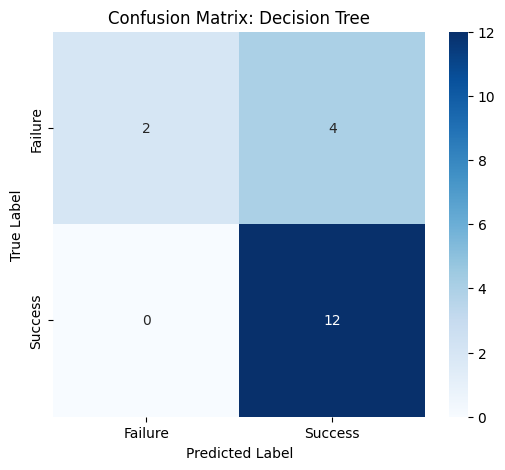

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix

parameters = {'criterion': ['gini', 'entropy'], 'splitter': ['best', 'random'], 
              'max_depth': [2, 4, 6], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5]}

tree_cv = GridSearchCV(DecisionTreeClassifier(), parameters, cv=10)
tree_cv.fit(X_train, Y_train)

yhat = tree_cv.predict(X_test)
cm = confusion_matrix(Y_test, yhat)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', 
            xticklabels=['Failure', 'Success'], yticklabels=['Failure', 'Success'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Decision Tree')
plt.show()